In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/._trimaps
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/README
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/test.txt
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/trainval.txt
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/list.txt
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/staffordshire_bull_terrier_165.xml
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/saint_bernard_182.xml
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/Birman_151.xml
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/British_Shorthair_180.xml
/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/annotations/xmls/Birman_15

In [8]:
import os
import random
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Ensure reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
def apply_salt_and_pepper(img_tensor):
    p = random.uniform(0.02, 0.15)
    mask = torch.rand(img_tensor.shape[1:]) # [H, W]
    corrupted = img_tensor.clone()
    corrupted[:, mask < p/2] = 1.0 # Salt (White)
    corrupted[:, (mask >= p/2) & (mask < p)] = 0.0 # Pepper (Black)
    return corrupted

def apply_gaussian_blur(img_tensor):
    k = random.choice([3, 5, 7])
    sigma = random.uniform(0.5, 2.5)
    return TF.gaussian_blur(img_tensor, kernel_size=[k, k], sigma=[sigma, sigma])

def apply_occlusion(img_tensor):
    c, h, w = img_tensor.shape
    num_rects = random.randint(1, 3)
    target_area_ratio = random.uniform(0.10, 0.35)
    total_area = h * w
    area_per_rect = (target_area_ratio * total_area) / num_rects
    
    corrupted = img_tensor.clone()
    for _ in range(num_rects):
        aspect_ratio = random.uniform(0.5, 2.0)
        rect_h = max(1, min(h, int((area_per_rect * aspect_ratio) ** 0.5)))
        rect_w = max(1, min(w, int((area_per_rect / aspect_ratio) ** 0.5)))
        
        top = random.randint(0, max(1, h - rect_h))
        left = random.randint(0, max(1, w - rect_w))
        
        corrupted[:, top:top+rect_h, left:left+rect_w] = 0.0 # Black out the region
    return corrupted

def apply_random_corruption(img_tensor, is_training=True, seed=None):
    """
    Applies one of the four corruptions dynamically.
    For validation, we pass a seed to make the corruption deterministic (manifest).
    """
    if not is_training and seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)
        
    choice = random.randint(0, 3)
    
    if choice == 0:
        corrupted = img_tensor.clone()
        label = "Clean"
    elif choice == 1:
        corrupted = apply_salt_and_pepper(img_tensor)
        label = "Salt & Pepper"
    elif choice == 2:
        corrupted = apply_gaussian_blur(img_tensor)
        label = "Gaussian Blur"
    else:
        corrupted = apply_occlusion(img_tensor)
        label = "Occlusion"
        
    # Reset seed to random if we fixed it for validation
    if not is_training:
        random.seed()
        torch.seed()
        
    return corrupted, choice, label

In [10]:
class PetCorruptionDataset(Dataset):
    root_dir = "/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet"
    
    def __init__(self, root_dir, is_training=True):
        # Base transform: Resize to 128x128 and convert to Tensor [0, 1]
        self.base_transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])
        
        # Load the dataset (Kaggle usually has the images inside an 'images' folder)
        import glob
        from PIL import Image
        
        # Grab all jpgs
        self.image_paths = sorted(glob.glob(os.path.join(root_dir, "images", "*.jpg")))
        if len(self.image_paths) == 0:
             print(f"Warning: No images found in {os.path.join(root_dir, 'images')}")
        
        # The assignment requires an 80/20 train/val split using seed 42.
        dataset_size = len(self.image_paths)
        indices = list(range(dataset_size))
        np.random.seed(42)
        np.random.shuffle(indices)
        split_idx = int(np.floor(0.2 * dataset_size)) # 20% for val
        
        if is_training:
            self.indices = indices[split_idx:]
        else:
            self.indices = indices[:split_idx]
            
        self.is_training = is_training
        
    def __len__(self):
        return len(self.indices)
        
    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        img_path = self.image_paths[actual_idx]
        
        # Load image and convert to RGB (some might be grayscale or have alpha channel)
        from PIL import Image
        clean_img = Image.open(img_path).convert("RGB")
        clean_tensor = self.base_transform(clean_img)
        
        # For validation, we use the actual dataset index as a seed so it is completely deterministic
        seed = None if self.is_training else actual_idx
        
        corrupted_tensor, corruption_idx, corruption_label = apply_random_corruption(clean_tensor, self.is_training, seed)

        return corrupted_tensor, clean_tensor, corruption_idx
       # return corrupted_tensor, clean_tensor, corruption_label

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class CorruptionClassifier(nn.Module):
    def __init__(self, base_channels=16, dropout_rate=0.3):
        super(CorruptionClassifier, self).__init__()
        
        # We use Max Pooling to shrink the image and look for "features" of corruption
        self.conv_layers = nn.Sequential(
            # Input: 3 x 128 x 128
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # 64x64
            
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # 32x32
            
            nn.Conv2d(base_channels*2, base_channels*4, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # 16x16
            
            nn.Conv2d(base_channels*4, base_channels*8, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 8x8
        )
        
        flattened_size = (base_channels * 8) * 8 * 8
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 4) # 4 output classes!
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        logits = self.fc_layers(x)
        # Note: We return raw logits because PyTorch's CrossEntropyLoss 
        # applies the Softmax automatically under the hood!
        return logits

In [12]:

# (Make sure KAGGLE_DATA_DIR matches what you used in Step 1)
KAGGLE_DATA_DIR = "/kaggle/input/datasets/mishalfatima09/oxford-iiit-pet/oxford-iiit-pet/images" 
val_dataset = PetCorruptionDataset(root_dir=KAGGLE_DATA_DIR, is_training=False)
train_dataset = PetCorruptionDataset(root_dir=KAGGLE_DATA_DIR, is_training=True)


In [13]:
import optuna
import torch.optim as optim
from sklearn.metrics import accuracy_score

def classifier_objective(trial):
    # 1. Ask Optuna for hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    base_channels = trial.suggest_categorical("base_channels", [16, 32])
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    
    # 2. Setup DataLoaders
    # (Reusing train_dataset and val_dataset from Task 1)
    
    train_dataset = PetCorruptionDataset(root_dir=KAGGLE_DATA_DIR, is_training=True)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # 3. Setup Model, Loss (CrossEntropy for classification), Optimizer
    model = CorruptionClassifier(base_channels=base_channels, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # 4. Train for a short budget (3 epochs) to test this config
    num_epochs = 3 
    for epoch in range(num_epochs):
        model.train()
        for corrupted, _, labels in train_loader:
            corrupted, labels = corrupted.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(corrupted)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
        # Validation Pass
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for corrupted, _, labels in val_loader:
                corrupted, labels = corrupted.to(device), labels.to(device)
                outputs = model(corrupted)
                # Get the class with the highest probability
                preds = torch.argmax(outputs, dim=1) 
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        # Calculate Validation Accuracy
        val_acc = accuracy_score(all_labels, all_preds)
        
        # Report for pruning
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    # Our goal is to MAXIMIZE accuracy
    return val_acc 

print("Starting Classifier Optuna Search...")
# Notice direction is "maximize" because we want high accuracy!
clf_study = optuna.create_study(direction="maximize")
clf_study.optimize(classifier_objective, n_trials=5)

print("\n--- CLASSIFIER OPTUNA SEARCH COMPLETE ---")
best_clf_trial = clf_study.best_trial
print(f"Best trial accuracy: {best_clf_trial.value:.4f}")
print("Best Hyperparameters: ")
for key, value in best_clf_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-10-02 15:37:32,839] A new study created in memory with name: no-name-1ef69723-71d2-4570-8335-a8c0929267e7


Starting Classifier Optuna Search...


[I 2026-10-02 15:39:26,025] Trial 0 finished with value: 0.9235453315290933 and parameters: {'lr': 0.00040717684949189873, 'batch_size': 16, 'base_channels': 32, 'dropout_rate': 0.2813513720278239, 'weight_decay': 7.504866080593267e-05}. Best is trial 0 with value: 0.9235453315290933.
[I 2026-10-02 15:40:42,005] Trial 1 finished with value: 0.8775372124492558 and parameters: {'lr': 0.00010528863254966129, 'batch_size': 64, 'base_channels': 32, 'dropout_rate': 0.2485809325155834, 'weight_decay': 6.972578831939894e-05}. Best is trial 0 with value: 0.9235453315290933.
[I 2026-10-02 15:41:58,242] Trial 2 finished with value: 0.8802435723951285 and parameters: {'lr': 0.00014528641816891495, 'batch_size': 64, 'base_channels': 32, 'dropout_rate': 0.15894728779976203, 'weight_decay': 4.598306002812026e-05}. Best is trial 0 with value: 0.9235453315290933.
[I 2026-10-02 15:43:13,263] Trial 3 finished with value: 0.9722598105548038 and parameters: {'lr': 0.007305978139852131, 'batch_size': 32, 'b


--- CLASSIFIER OPTUNA SEARCH COMPLETE ---
Best trial accuracy: 0.9723
Best Hyperparameters: 
    lr: 0.007305978139852131
    batch_size: 32
    base_channels: 32
    dropout_rate: 0.14158065375819204
    weight_decay: 1.802097150098098e-05


In [16]:
!pip install -q onnx onnxscript

Training Final Classifier with Best Hyperparameters...
Epoch 1/10 complete.
Epoch 2/10 complete.
Epoch 3/10 complete.
Epoch 4/10 complete.
Epoch 5/10 complete.
Epoch 6/10 complete.
Epoch 7/10 complete.
Epoch 8/10 complete.
Epoch 9/10 complete.
Epoch 10/10 complete.

Evaluating Final Classifier on Validation Set...

--- CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

        Clean (0)       0.86      0.02      0.03       346
    S&P Noise (1)       1.00      1.00      1.00       371
Gaussian Blur (2)       0.52      0.99      0.68       369
    Occlusion (3)       1.00      1.00      1.00       392

         accuracy                           0.77      1478
        macro avg       0.84      0.75      0.68      1478
     weighted avg       0.85      0.77      0.69      1478



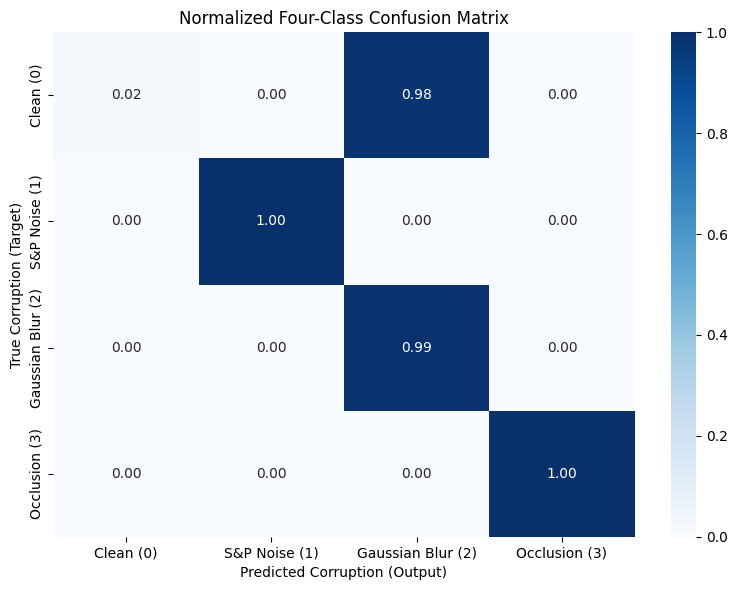

/tmp/ipykernel_58/3649084354.py:72: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1002 16:02:01.768000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W1002 16:02:01.770000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W1002 16:02:01.772000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' 

[torch.onnx] Obtain model graph for `CorruptionClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CorruptionClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅

Classifier exported to corruption_classifier.onnx


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

print("Training Final Classifier with Best Hyperparameters...")
best_params = clf_study.best_trial.params

# Setup final DataLoaders
final_clf_train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True, num_workers=2)
final_clf_val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False, num_workers=2)

# Initialize best model
final_classifier = CorruptionClassifier(
    base_channels=best_params['base_channels'], 
    dropout_rate=best_params['dropout_rate']
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_classifier.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])

# Train for 10 epochs for the final evaluation
num_epochs = 10
for epoch in range(num_epochs):
    final_classifier.train()
    for corrupted, _, labels in final_clf_train_loader:
        corrupted, labels = corrupted.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_classifier(corrupted)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs} complete.")

# Save weights
torch.save(final_classifier.state_dict(), "corruption_classifier_best.pth")

# --- EVALUATION ---
print("\nEvaluating Final Classifier on Validation Set...")
final_classifier.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for corrupted, _, labels in final_clf_val_loader:
        corrupted, labels = corrupted.to(device), labels.to(device)
        outputs = final_classifier(corrupted)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 1. Strict Requirement: Classification Report (Accuracy, Precision, Recall, F1)
target_names = ["Clean (0)", "S&P Noise (1)", "Gaussian Blur (2)", "Occlusion (3)"]
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

# 2. Strict Requirement: Normalized 4-Class Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')

plt.figure(figsize=(8, 6))
# fmt=".2f" ensures we display percentages/probabilities correctly
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Normalized Four-Class Confusion Matrix")
plt.ylabel("True Corruption (Target)")
plt.xlabel("Predicted Corruption (Output)")
plt.tight_layout()
plt.show()

# 3. Export to ONNX (using the fix from earlier!)
onnx_file_path = "corruption_classifier.onnx"
dummy_input = torch.randn(1, 3, 128, 128).to(device)

torch.onnx.export(
    final_classifier, 
    dummy_input, 
    onnx_file_path,
    export_params=True, 
    opset_version=18, 
    do_constant_folding=True,
    input_names=['input'], 
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print(f"\nClassifier exported to {onnx_file_path}")

In [18]:
class SpecialistDataset(PetCorruptionDataset):
    def __init__(self, root_dir, corruption_idx, is_training=True):
        # Initialize the parent class
        super().__init__(root_dir, is_training)
        # Force it to only generate this specific corruption!
        # (1 = S&P, 2 = Blur, 3 = Occlusion)
        self.corruption_idx = corruption_idx
        
    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        img_path = self.image_paths[actual_idx]
        from PIL import Image
        clean_img = Image.open(img_path).convert("RGB")
        clean_tensor = self.base_transform(clean_img)
        
        # Set a deterministic seed for validation, just like Task 1
        if not self.is_training:
            random.seed(actual_idx)
            torch.manual_seed(actual_idx)
            
        # Apply specifically targeted corruption
        if self.corruption_idx == 1:
            corrupted_tensor = apply_salt_and_pepper(clean_tensor)
        elif self.corruption_idx == 2:
            corrupted_tensor = apply_gaussian_blur(clean_tensor)
        elif self.corruption_idx == 3:
            corrupted_tensor = apply_occlusion(clean_tensor)
            
        if not self.is_training:
            random.seed()
            torch.seed()
            
        return corrupted_tensor, clean_tensor

In [ ]:
import time
from torchmetrics.image import StructuralSimilarityIndexMeasure

# 1. The Autoencoder Architecture
class UniversalAutoencoder(nn.Module):
    def __init__(self, bottleneck_dim=256, base_channels=32, dropout_rate=0.0):
        super(UniversalAutoencoder, self).__init__()
        self.base_channels = base_channels
        self.encoder = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(base_channels, base_channels*2, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(base_channels*2, base_channels*4, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(base_channels*4, base_channels*8, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Flatten()
        )
        flattened_size = 8 * 8 * (base_channels * 8)
        self.fc_encode = nn.Linear(flattened_size, bottleneck_dim)
        self.fc_decode = nn.Linear(bottleneck_dim, flattened_size)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_channels*8, base_channels*4, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.ConvTranspose2d(base_channels*4, base_channels*2, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=4, stride=2, padding=1), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.ConvTranspose2d(base_channels, 3, kernel_size=4, stride=2, padding=1), nn.Sigmoid() 
        )
    def forward(self, x):
        x = self.encoder(x)
        latent = self.fc_encode(x)
        x = self.fc_decode(latent)
        x = x.view(-1, self.base_channels * 8, 8, 8) 
        return self.decoder(x)

# 2. The Combined Loss Function
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.8, device='cpu'):
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.l1_loss = nn.L1Loss()
        self.ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    def forward(self, pred, target):
        l1 = self.l1_loss(pred, target)
        ssim_loss = 1.0 - self.ssim(pred, target)
        return (self.alpha * l1) + ((1.0 - self.alpha) * ssim_loss), l1, ssim_loss

# 3. The Training Loop Helper
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'val_loss': [], 'train_ssim': [], 'val_ssim': []}
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        running_loss, running_ssim = 0.0, 0.0
        for corrupted, clean in train_loader:
            corrupted, clean = corrupted.to(device), clean.to(device)
            optimizer.zero_grad()
            outputs = model(corrupted)
            loss, _, ssim_loss = criterion(outputs, clean)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * corrupted.size(0)
            running_ssim += (1.0 - ssim_loss.item()) * corrupted.size(0)
        
        model.eval()
        val_loss, val_ssim = 0.0, 0.0
        with torch.no_grad():
            for corrupted, clean in val_loader:
                corrupted, clean = corrupted.to(device), clean.to(device)
                outputs = model(corrupted)
                loss, _, ssim_loss = criterion(outputs, clean)
                val_loss += loss.item() * corrupted.size(0)
                val_ssim += (1.0 - ssim_loss.item()) * corrupted.size(0)
                
        print(f"Epoch {epoch+1}/{num_epochs} [{time.time() - start_time:.0f}s] "
              f"Train Loss: {running_loss/len(train_loader.dataset):.4f} | "
              f"Val Loss: {val_loss/len(val_loader.dataset):.4f}")
    return history

In [20]:
class SpecialistDataset(PetCorruptionDataset):
    def __init__(self, root_dir, corruption_idx, is_training=True):
        # Initialize the parent class
        super().__init__(root_dir, is_training)
        # Force it to only generate this specific corruption!
        # (1 = S&P, 2 = Blur, 3 = Occlusion)
        self.corruption_idx = corruption_idx
        
    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        img_path = self.image_paths[actual_idx]
        from PIL import Image
        clean_img = Image.open(img_path).convert("RGB")
        clean_tensor = self.base_transform(clean_img)
        
        # Set a deterministic seed for validation, just like Task 1
        if not self.is_training:
            random.seed(actual_idx)
            torch.manual_seed(actual_idx)
            
        # Apply specifically targeted corruption
        if self.corruption_idx == 1:
            corrupted_tensor = apply_salt_and_pepper(clean_tensor)
        elif self.corruption_idx == 2:
            corrupted_tensor = apply_gaussian_blur(clean_tensor)
        elif self.corruption_idx == 3:
            corrupted_tensor = apply_occlusion(clean_tensor)
            
        if not self.is_training:
            random.seed()
            torch.seed()
            
        return corrupted_tensor, clean_tensor

In [ ]:
# --- TASK 1 OPTUNA RESULTS ---
BEST_LR = 0.0014581905063314482
BEST_BATCH = 64
BEST_BOTTLENECK = 128
BEST_CHANNELS = 16
BEST_DROPOUT = 0.03416438462676974
BEST_ALPHA = 0.8009521704058383

specialist_names = {
    1: "Salt & Pepper",
    2: "Gaussian Blur",
    3: "Occlusion"
}

# We will store the trained models in a dictionary
trained_specialists = {}

for c_idx, name in specialist_names.items():
    print(f"\n{'='*50}")
    print(f"TRAINING SPECIALIST: {name}")
    print(f"{'='*50}")
    
    # 1. Create specific datasets
    s_train_ds = SpecialistDataset(root_dir=KAGGLE_DATA_DIR, corruption_idx=c_idx, is_training=True)
    s_val_ds = SpecialistDataset(root_dir=KAGGLE_DATA_DIR, corruption_idx=c_idx, is_training=False)
    
    s_train_loader = DataLoader(s_train_ds, batch_size=BEST_BATCH, shuffle=True, num_workers=2)
    s_val_loader = DataLoader(s_val_ds, batch_size=BEST_BATCH, shuffle=False, num_workers=2)
    
    # 2. Initialize Model
    s_model = UniversalAutoencoder(
        bottleneck_dim=BEST_BOTTLENECK, 
        base_channels=BEST_CHANNELS, 
        dropout_rate=BEST_DROPOUT
    ).to(device)
    
    s_criterion = CombinedLoss(alpha=BEST_ALPHA, device=device)
    s_optimizer = optim.Adam(s_model.parameters(), lr=BEST_LR)
    
    # 3. Train (e.g., 5 epochs to keep it fast for now)
    train_model(s_model, s_train_loader, s_val_loader, s_criterion, s_optimizer, num_epochs=5)
    
    # 4. Save the expert weights and ONNX model!
    weights_name = f"specialist_{c_idx}.pth"
    onnx_name = f"specialist_{c_idx}.onnx"
    
    torch.save(s_model.state_dict(), weights_name)
    
    dummy_input = torch.randn(1, 3, 128, 128).to(device)
    torch.onnx.export(s_model, dummy_input, onnx_name, export_params=True, opset_version=18, 
                      do_constant_folding=True, input_names=['input'], output_names=['output'],
                      dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})
    
    print(f"Saved {name} Specialist to {weights_name} and {onnx_name}")
    
    trained_specialists[c_idx] = s_model


TRAINING SPECIALIST: Salt & Pepper
Epoch 1/5 [37s] Train Loss: 0.2804 | Val Loss: 0.2435
Epoch 2/5 [26s] Train Loss: 0.2248 | Val Loss: 0.2076
Epoch 3/5 [26s] Train Loss: 0.2071 | Val Loss: 0.1955
Epoch 4/5 [26s] Train Loss: 0.1989 | Val Loss: 0.1947
Epoch 5/5 [26s] Train Loss: 0.1938 | Val Loss: 0.1876


/tmp/ipykernel_58/2944365097.py:50: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(s_model, dummy_input, onnx_name, export_params=True, opset_version=18,
W1002 16:07:11.218000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W1002 16:07:11.220000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W1002 16:07:11.222000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' fro

[torch.onnx] Obtain model graph for `UniversalAutoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `UniversalAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Saved Salt & Pepper Specialist to specialist_1.pth and specialist_1.onnx

TRAINING SPECIALIST: Gaussian Blur


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


Epoch 1/5 [28s] Train Loss: 0.2789 | Val Loss: 0.2494
Epoch 2/5 [29s] Train Loss: 0.2421 | Val Loss: 0.2337
Epoch 3/5 [28s] Train Loss: 0.2252 | Val Loss: 0.2053
Epoch 4/5 [28s] Train Loss: 0.2034 | Val Loss: 0.1987
Epoch 5/5 [27s] Train Loss: 0.1954 | Val Loss: 0.1916


/tmp/ipykernel_58/2944365097.py:50: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(s_model, dummy_input, onnx_name, export_params=True, opset_version=18,
W1002 16:09:32.226000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W1002 16:09:32.229000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W1002 16:09:32.230000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' fro

[torch.onnx] Obtain model graph for `UniversalAutoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `UniversalAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Saved Gaussian Blur Specialist to specialist_2.pth and specialist_2.onnx

TRAINING SPECIALIST: Occlusion


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


Epoch 1/5 [25s] Train Loss: 0.2830 | Val Loss: 0.2529
Epoch 3/5 [25s] Train Loss: 0.2281 | Val Loss: 0.2121


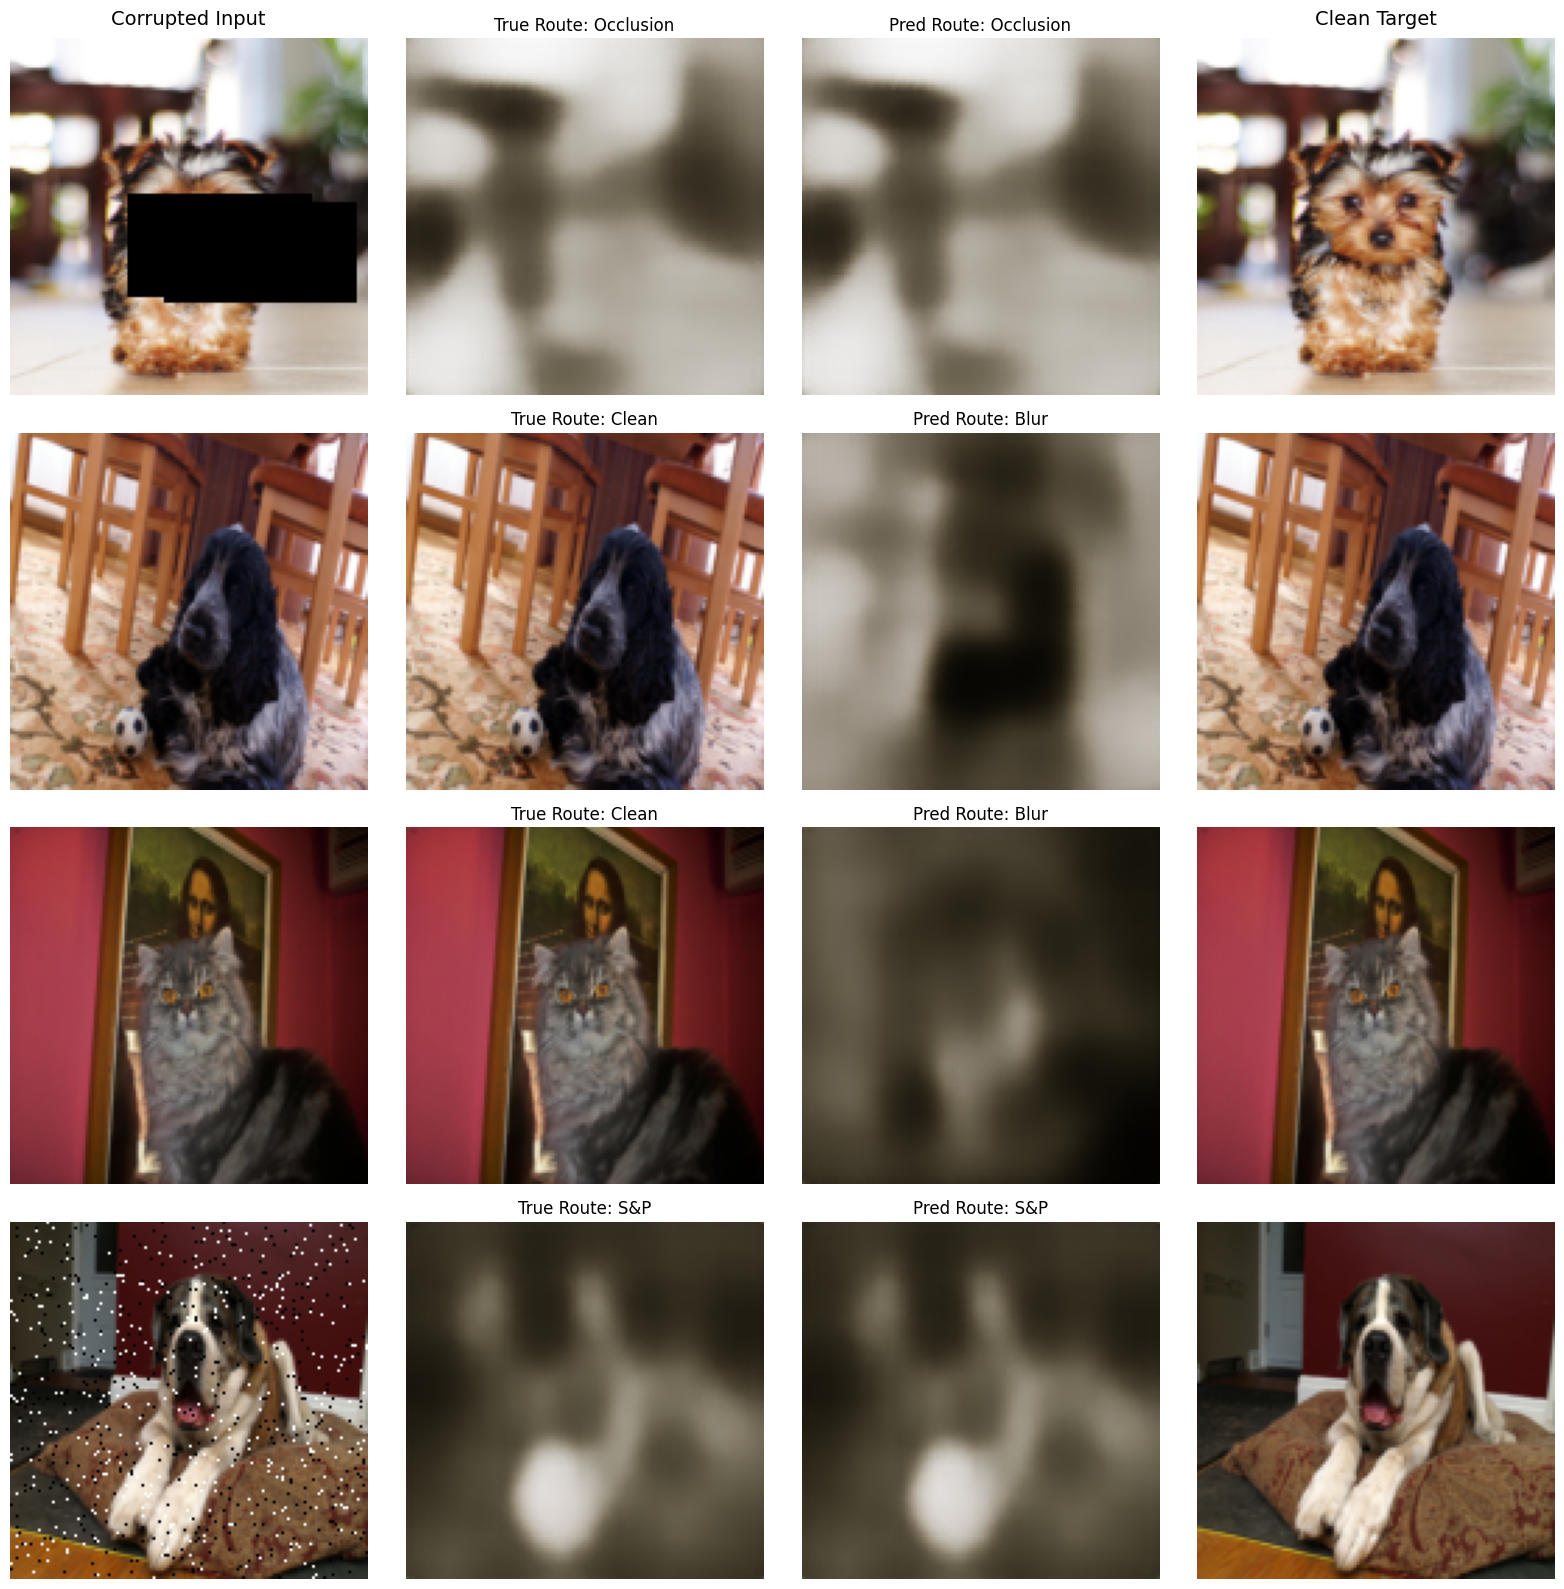

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. The Hard-Routing Function
def hard_routing_inference(corrupted_batch, routing_labels, specialists_dict):
    """
    Routes each image in the batch to the correct specialist based on the routing_labels array.
    If routing_labels == 0 (Clean), it returns the input unchanged (Identity Bypass).
    """
    batch_size = corrupted_batch.size(0)
    restored_batch = torch.zeros_like(corrupted_batch)
    
    for i in range(batch_size):
        img = corrupted_batch[i].unsqueeze(0) # Shape: [1, 3, 128, 128]
        label = routing_labels[i].item()
        
        if label == 0:
            # IDENTITY BYPASS: Clean image passes straight through
            restored_batch[i] = img.squeeze(0)
        else:
            # Route to specific expert
            expert_model = specialists_dict[label]
            expert_model.eval()
            with torch.no_grad():
                restored_batch[i] = expert_model(img).squeeze(0)
                
    return restored_batch

# --- 2. TESTING THE PIPELINE ---

# We'll use your original val_loader (from step 1) because it has a randomized mix of all 4 conditions
corrupted_imgs, clean_imgs, true_labels = next(iter(final_clf_val_loader))
corrupted_imgs, clean_imgs, true_labels = corrupted_imgs.to(device), clean_imgs.to(device), true_labels.to(device)

# A. Oracle Routing (Using the TRUE labels as the router)
oracle_restored = hard_routing_inference(corrupted_imgs, true_labels, trained_specialists)

# B. Predicted Routing (Using the CLASSIFIER predictions as the router)
final_classifier.eval()
with torch.no_grad():
    classifier_outputs = final_classifier(corrupted_imgs)
    predicted_labels = torch.argmax(classifier_outputs, dim=1)

predicted_restored = hard_routing_inference(corrupted_imgs, predicted_labels, trained_specialists)

# --- 3. VISUALIZATION ---
# Convert everything to CPU numpy for matplotlib
corrupted_np = corrupted_imgs.cpu().permute(0, 2, 3, 1).numpy()
clean_np = clean_imgs.cpu().permute(0, 2, 3, 1).numpy()
oracle_np = oracle_restored.cpu().permute(0, 2, 3, 1).numpy()
predicted_np = predicted_restored.cpu().permute(0, 2, 3, 1).numpy()
true_labels_np = true_labels.cpu().numpy()
predicted_labels_np = predicted_labels.cpu().numpy()

class_names = {0: "Clean", 1: "S&P", 2: "Blur", 3: "Occlusion"}

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
col_titles = ['Corrupted Input', 'Oracle Mode (Perfect)', 'Predicted Mode (Real)', 'Clean Target']

for ax, col in zip(axes[0], col_titles):
    ax.set_title(col, fontsize=14, pad=10)

for i in range(4):
    # 1. Input
    axes[i, 0].imshow(corrupted_np[i])
    axes[i, 0].axis('off')
    
    # 2. Oracle Restored
    axes[i, 1].imshow(oracle_np[i])
    axes[i, 1].set_title(f"True Route: {class_names[true_labels_np[i]]}")
    axes[i, 1].axis('off')
    
    # 3. Predicted Restored
    axes[i, 2].imshow(predicted_np[i])
    axes[i, 2].set_title(f"Pred Route: {class_names[predicted_labels_np[i]]}")
    axes[i, 2].axis('off')
    
    # 4. Target
    axes[i, 3].imshow(clean_np[i])
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()